# JW $\mathbb{Z}_2^F \times \mathbb{Z}_2^T$

Created: 17-09-2026

Objectives:
* Iterate on [this notebook](jw_z_4_tf_system_cocycle_extraction_larger_system.ipynb), now apply to $\mathbb{Z}_2^F \times \mathbb{Z}_2^T$ systems. We rely on the systems in [this paper](10.1103/PhysRevB.96.165124). The symmetries are given by fermion parity and complex conjugation in the fermionic system. After $JW$ transformation, this becomes $Z$ and complex conjugation.
* After JW transformation, the four states we consider are those stabilized by $YZY$, $Z$, $XZX$ and $XZZZX$.
* We apply random unitaries. The two site random unitaries are given by $U_0 \oplus U_1$, where each $U_i \in O(2)$ and $U_0$ lives in $\ket{00}, \ket{11}$ and $U_1$ lives in $\ket{01}, \ket{10}$.

# Imports

In [1]:
import numpy as np

In [2]:
import jax
jax.config.update('jax_platform_name', 'cpu')

import jax.numpy as jnp

In [3]:
import matplotlib.pyplot as plt

In [4]:
from tqdm import tqdm

In [5]:
from functools import reduce
from operator import mul
from itertools import product

In [6]:
from random import random

In [7]:
import quimb.tensor as qtn
import quimb as qu

In [8]:
from scipy.stats import unitary_group

In [9]:
from collections import Counter

In [10]:
import pandas as pd

In [11]:
from time import time

In [12]:
from humanize import naturalsize

# Definitions
## Construct states

### Z product state

In [13]:
np_up_Z_state = np.array([1,0])

In [14]:
qu_up_Z_state = qtn.Tensor(
    data=np_up_Z_state,
    inds=('k',),
    tags='prod'
)

In [15]:
def get_product_qu_tensor_network(num_sites):
    assert (num_sites%2) == 0

    product_state_tensors = [
        qu_up_Z_state.reindex({'k': f'k{i}'})
        for i in range(num_sites)
    ]

    out = qtn.TensorNetwork(
        product_state_tensors,
        virtual=True
    )
    out.mangle_inner_()

    return out

ERROR! Session/line number was not unique in database. History logging moved to new session 3


### XZX cluster state

In [16]:
np_up_X_state = 1/(np.sqrt(2))*np.array([1,1])

In [17]:
qu_up_X_state = qtn.Tensor(
    data=np_up_X_state,
    inds=('k',),
    tags='prod'
)

In [18]:
np_CZ = np.diag([1,1,1,-1])

In [19]:
np_CZ = np_CZ.reshape((2,)*4)

In [20]:
qu_CZ = qtn.Tensor(
    data=np_CZ,
    inds=('k1', 'k2', 'b1', 'b2'),
    tags='CZ'
)

In [21]:
np_hadamard = np.pow(2, -1/2)*np.array([
    [1,1],
    [1,-1]
])

In [22]:
qu_hadamard = qtn.Tensor(data=np_hadamard, inds=('k', 'b'), tags='Had')

In [23]:
def get_xzx_cluster_state_qu_tensor_network(num_sites):
    assert (num_sites%2) == 0

    product_state_tensors = [
        qu_up_X_state.reindex({'k': f'kc_1_{i}'})
        for i in range(num_sites)
    ]

    first_layer_circuit_tensors = [
        qu_CZ.reindex({
            'b1': f'kc_1_{i}',
            'b2': f'kc_1_{i+1}',
            'k1': f'kc_2_{i}',
            'k2': f'kc_2_{i+1}'
        })
        for i in range(0, num_sites, 2)
    ]


    second_layer_circuit_tensors = [
        qu_CZ.reindex({
            'b1': f'kc_2_{i}',
            'b2': f'kc_2_{(i+1)%num_sites}',
            'k1': f'k_3_{i}',
            'k2': f'k_3_{(i+1)%num_sites}'
        })
        for i in range(1, num_sites+1, 2)
    ]

    hadamard_layer = [
        qu_hadamard.reindex({
            'b': f'k_3_{i}',
            'k': f'k{i}'
        })
        for i in range(num_sites)
    ]
    all_tensors = (
        product_state_tensors
        + first_layer_circuit_tensors
        + second_layer_circuit_tensors
        + hadamard_layer
    )

    out = qtn.TensorNetwork(all_tensors, virtual=True)
    out.mangle_inner_()

    return out

### YZY cluster state

In [24]:
np_S = np.array([
    [1,0],
    [0,1j]
])

In [25]:
np_xyz_rotator = np_S @ np_hadamard

In [26]:
qu_xyz_rotator = qtn.Tensor(data=np_xyz_rotator, inds=('k', 'b'), tags='xyz_rot')

In [27]:
def get_yzy_cluster_state_qu_tensor_network(num_sites):
    assert (num_sites%2) == 0

    product_state_tensors = [
        qu_up_X_state.reindex({'k': f'kc_1_{i}'})
        for i in range(num_sites)
    ]

    first_layer_circuit_tensors = [
        qu_CZ.reindex({
            'b1': f'kc_1_{i}',
            'b2': f'kc_1_{i+1}',
            'k1': f'kc_2_{i}',
            'k2': f'kc_2_{i+1}'
        })
        for i in range(0, num_sites, 2)
    ]


    second_layer_circuit_tensors = [
        qu_CZ.reindex({
            'b1': f'kc_2_{i}',
            'b2': f'kc_2_{(i+1)%num_sites}',
            'k1': f'k_3_{i}',
            'k2': f'k_3_{(i+1)%num_sites}'
        })
        for i in range(1, num_sites+1, 2)
    ]

    rotator_layer = [
        qu_xyz_rotator.reindex({
            'b': f'k_3_{i}',
            'k': f'k{i}'
        })
        for i in range(num_sites)
    ]
    all_tensors = (
        product_state_tensors
        + first_layer_circuit_tensors
        + second_layer_circuit_tensors
        + rotator_layer
    )

    out = qtn.TensorNetwork(all_tensors, virtual=True)
    out.mangle_inner_()

    return out

### XZZZX cluster state
$$ \ket\psi = H^{\otimes N} S^{\otimes N} (\prod_j CZ_{j,j+1}) H^{\otimes N} S^{\dagger \otimes N} (\prod_j CZ_{j,j+1}) \ket{+}^{\otimes N}$$

In [28]:
qu_S = qtn.Tensor(data=np_S, inds=('k', 'b'), tags='S')

In [76]:
def get_xzzzx_cluster_state_qu_tensor_network(num_sites):
    assert (num_sites%2) == 0

    product_state_tensors = [
        qu_up_X_state.reindex({'k': f'k_1_{i}'})
        for i in range(num_sites)
    ]

    first_layer_circuit_tensors = [
        qu_CZ.reindex({
            'b1': f'k_1_{i}',
            'b2': f'k_1_{i+1}',
            'k1': f'k_2_{i}',
            'k2': f'k_2_{i+1}'
        })
        for i in range(0, num_sites, 2)
    ]


    second_layer_circuit_tensors = [
        qu_CZ.reindex({
            'b1': f'k_2_{i}',
            'b2': f'k_2_{(i+1)%num_sites}',
            'k1': f'k_3_{i}',
            'k2': f'k_3_{(i+1)%num_sites}'
        })
        for i in range(1, num_sites+1, 2)
    ]

    first_s_layer = [
        qu_S.conj().reindex({
            'b': f'k_3_{i}',
            'k': f'k_4_{i}'
        })
        for i in range(num_sites)
    ]

    first_hadamard_layer = [
        qu_hadamard.reindex({
            'b': f'k_4_{i}',
            'k': f'k_5_{i}'
        })
        for i in range(num_sites)
    ]

    third_layer_circuit_tensors = [
        qu_CZ.reindex({
            'b1': f'k_5_{i}',
            'b2': f'k_5_{i+1}',
            'k1': f'k_6_{i}',
            'k2': f'k_6_{i+1}'
        })
        for i in range(0, num_sites, 2)
    ]

    fourth_layer_circuit_tensors = [
        qu_CZ.reindex({
            'b1': f'k_6_{i}',
            'b2': f'k_6_{(i+1)%num_sites}',
            'k1': f'k_7_{i}',
            'k2': f'k_7_{(i+1)%num_sites}'
        })
        for i in range(1, num_sites+1, 2)
    ]

    second_s_layer = [
        qu_S.reindex({
            'b': f'k_7_{i}',
            'k': f'k_8_{i}'
        })
        for i in range(num_sites)
    ]

    second_hadamard_layer = [
        qu_hadamard.reindex({
            'b': f'k_8_{i}',
            'k': f'k{i}'
        })
        for i in range(num_sites)
    ]

    all_tensors = (
        product_state_tensors
        + first_layer_circuit_tensors
        + second_layer_circuit_tensors
        + first_s_layer
        + first_hadamard_layer
        + third_layer_circuit_tensors
        + fourth_layer_circuit_tensors
        + second_s_layer
        + second_hadamard_layer
    )

    out = qtn.TensorNetwork(all_tensors, virtual=True)
    out.mangle_inner_()

    return out

### Check states

In [30]:
num_sites = 32

In [31]:
psi = get_product_qu_tensor_network(num_sites)

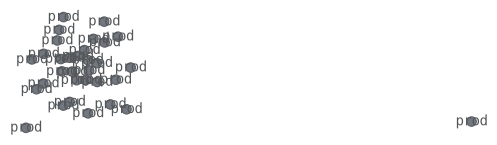

In [32]:
psi.draw()

In [33]:
np_Z = np.array([
    [1,0],
    [0,-1]
])

In [34]:
qu_Z = qtn.Tensor(data=np_Z, inds=('k', 'b'), tags='Z_gate')

In [35]:
gates = [
    qu_Z.reindex({'b': f'b{i}', 'k': f'k{i}'})
    for i in range(num_sites)
]

In [36]:
(psi & psi.conj()).contract()

np.float64(1.0)

In [37]:
i=0

In [38]:
gate_exps = [
    (
        psi
        & qu_Z.reindex({'b': f'b{i}', 'k': f'k{i}'})
        & (psi.conj().reindex({f'k{i}': f'b{i}'}))
    ).contract()
    for i in range(num_sites)
]

In [39]:
Counter(gate_exps)

Counter({np.float64(1.0): 32})

In [40]:
psi = get_xzx_cluster_state_qu_tensor_network(num_sites)

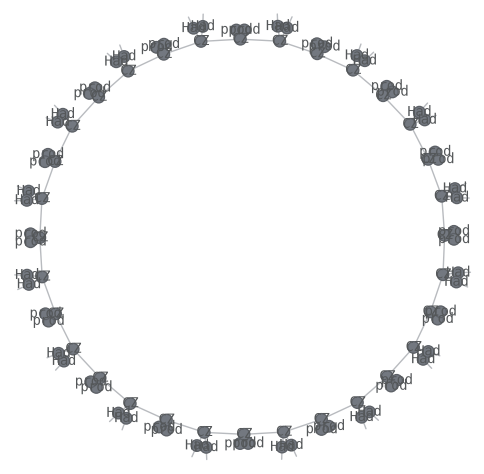

In [41]:
psi.draw()

In [42]:
(psi & psi.conj()).contract()

np.float64(1.0)

In [43]:
np_X = np.array([
    [0,1],
    [1,0]
])

In [44]:
qu_X = qtn.Tensor(data=np_X, inds=('k', 'b'), tags='X_gate')

In [45]:
i=0

In [46]:
gate_exps = [
    (
        psi
        & qu_X.reindex({'b': f'b{i}', 'k': f'k{i}'})
        & qu_Z.reindex({'b': f'b{(i+1)%num_sites}', 'k': f'k{(i+1)%num_sites}'})
        & qu_X.reindex({'b': f'b{(i+2)%num_sites}', 'k': f'k{(i+2)%num_sites}'})
        & (psi.conj().reindex({
            f'k{i}': f'b{i}',
            f'k{(i+1)%num_sites}': f'b{(i+1)%num_sites}',
            f'k{(i+2)%num_sites}': f'b{(i+2)%num_sites}'
        }))
    ).contract()
    for i in range(num_sites)
]

In [47]:
Counter(gate_exps)

Counter({np.float64(1.0): 31, np.float64(0.9999999999999998): 1})

In [48]:
psi = get_yzy_cluster_state_qu_tensor_network(num_sites)

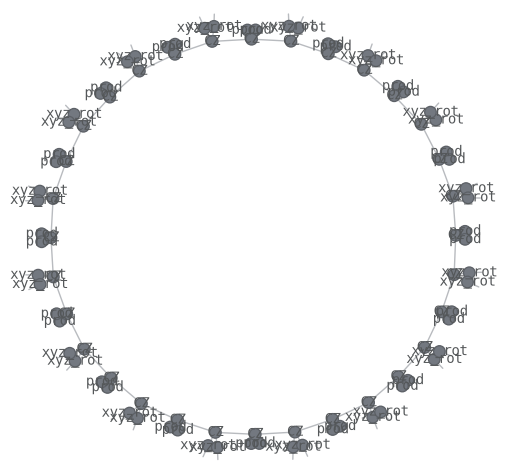

In [49]:
psi.draw()

In [50]:
(psi & psi.conj()).contract()

np.complex128(1+0j)

In [51]:
np_Y = np.array([
    [0,-1j],
    [1j,0]
])

In [52]:
qu_Y = qtn.Tensor(data=np_Y, inds=('k', 'b'), tags='Y_gate')

In [53]:
gate_exps = [
    (
        psi
        & qu_Y.reindex({'b': f'b{i}', 'k': f'k{i}'})
        & qu_Z.reindex({'b': f'b{(i+1)%num_sites}', 'k': f'k{(i+1)%num_sites}'})
        & qu_Y.reindex({'b': f'b{(i+2)%num_sites}', 'k': f'k{(i+2)%num_sites}'})
        & (psi.conj().reindex({
            f'k{i}': f'b{i}',
            f'k{(i+1)%num_sites}': f'b{(i+1)%num_sites}',
            f'k{(i+2)%num_sites}': f'b{(i+2)%num_sites}'
        }))
    ).contract()
    for i in range(num_sites)
]

In [54]:
Counter(gate_exps)

Counter({np.complex128(1+0j): 31, np.complex128(0.9999999999999998+0j): 1})

In [79]:
psi = get_xzzzx_cluster_state_qu_tensor_network(num_sites)

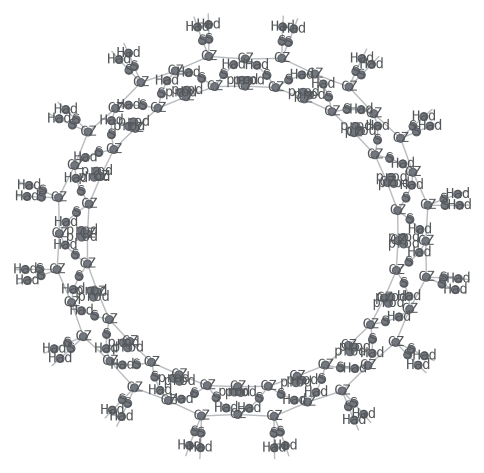

In [60]:
psi.draw()

In [61]:
(psi & psi.conj()).contract()

np.complex128(1.0000000000000073+0j)

In [80]:
gate_exps = [
    (
        psi
        & qu_X.reindex({'b': f'b{i}', 'k': f'k{i}'})
        & qu_Z.reindex({'b': f'b{(i+1)%num_sites}', 'k': f'k{(i+1)%num_sites}'})
        & qu_Z.reindex({'b': f'b{(i+2)%num_sites}', 'k': f'k{(i+2)%num_sites}'})
        & qu_Z.reindex({'b': f'b{(i+3)%num_sites}', 'k': f'k{(i+3)%num_sites}'})
        & qu_X.reindex({'b': f'b{(i+4)%num_sites}', 'k': f'k{(i+4)%num_sites}'})
        & (psi.conj().reindex({
            f'k{i}': f'b{i}',
            f'k{(i+1)%num_sites}': f'b{(i+1)%num_sites}',
            f'k{(i+2)%num_sites}': f'b{(i+2)%num_sites}',
            f'k{(i+3)%num_sites}': f'b{(i+3)%num_sites}',
            f'k{(i+4)%num_sites}': f'b{(i+4)%num_sites}',
        }))
    ).contract()
    for i in range(num_sites)
]

In [81]:
gate_exps[0]

np.complex128(1.0000000000000073+0j)

In [82]:
Counter(gate_exps)

Counter({np.complex128(1.0000000000000073+0j): 23,
         np.complex128(1.000000000000007+0j): 8,
         np.complex128(1.0000000000000069+0j): 1})

So the states are all correct!

## Construct product state

In [21]:
np_up_X_state = 1/(np.sqrt(2))*np.array([1,1])

In [22]:
np_up_Z_state = np.array([1,0])

In [23]:
qu_up_Z_state = qtn.Tensor(
    data=np_up_Z_state,
    inds=('k',),
    tags='prod'
)

In [24]:
alternating_states = [
    qu_up_X_state,
    qu_up_Z_state
]

def get_product_qu_tensor_network(num_sites):
    assert (num_sites%2) == 0

    product_state_tensors = [
        alternating_states[i%2].reindex({'k': f'k{i}'})
        for i in range(num_sites)
    ]

    out = qtn.TensorNetwork(
        product_state_tensors,
        virtual=True
    )
    out.mangle_inner_()

    return out

## Symmetries

In [25]:
def multikron(arrays):
    return reduce(np.kron, arrays)

In [26]:
np_I = np.array([
    [1,0],
    [0,1]
])

np_X = np.array([
    [0,1],
    [1,0]
])

np_Y = np.array([
    [0,-1j],
    [1j,0]
])

np_Z = np.array([
    [1,0],
    [0,-1]
])

In [27]:
qu_I = qtn.Tensor(
    np_I,
    inds=['k', 'b'],
    tags='X'
)

qu_X = qtn.Tensor(
    np_X,
    inds=['k', 'b'],
    tags='X'
)

qu_Y = qtn.Tensor(
    np_Y,
    inds=['k', 'b'],
    tags='Y'
)

qu_Z = qtn.Tensor(
    np_Z,
    inds=['k', 'b'],
    tags='Z'
)

In [28]:
def get_multisite_qu_X(num_sites):
    np_many_X = multikron([np_X]*num_sites)

    out = qtn.Tensor(
        np_many_X,
        inds=['k', 'b'],
        tags='mulit_site_X',
    )

    return out

In [29]:
def get_multisite_qu_I(num_sites):
    np_many_I = multikron([np_I]*num_sites)

    out = qtn.Tensor(
        np_many_I,
        inds=['k', 'b'],
        tags='mulit_site_I',
    )

    return out

In [30]:
qu_spin_fermion_fp = (
    qu_I.reindex({'k': 'ks', 'b': 'bs'})
    & qu_Z.reindex({'k': 'kf', 'b': 'bf'})
).contract()

qu_unit_cell_fp = qu_spin_fermion_fp.fuse({
    'k': ['ks', 'kf'],
    'b': ['bs', 'bf']
})

In [31]:
"""
def get_multisite_qu_fp(num_sites):
    assert (num_sites%2)==0

    num_unit_cells = (num_sites//2)

    np
"""

'\ndef get_multisite_qu_fp(num_sites):\n    assert (num_sites%2)==0\n\n    num_unit_cells = (num_sites//2)\n\n    np\n'

Decompose T symmetry as $MK$:

In [32]:
np_00 = np.array([[1,0], [0,0]])
np_11 = np.array([[0,0], [0,1]])

In [33]:
def tensor_product_operators(op_1, op_2):
    out = (
        op_1[..., np.newaxis, np.newaxis]
        *op_2[np.newaxis, np.newaxis, ...]
    )

    return out

In [34]:
np_M = (
    tensor_product_operators(np_X, np_00)
    + tensor_product_operators(np_Y, np_11)
)

In [35]:
qu_M = qtn.Tensor(
    np_M,
    inds=['ks', 'bs', 'kf', 'bf']
)

In [36]:
np_M_reindexed = (
    qu_M
    .fuse({
        'k': ['ks', 'kf'],
        'b': ['bs', 'bf']
    })
    .transpose('k', 'b')
    .data
)

## Extracting projectors

In [37]:
def random_uniform_complex(shape):
    return np.random.uniform(size=shape) + 1j*np.random.uniform(size=shape)

In [38]:
def maximize_projector_states(rho, left_sites, proj_sites, right_sites):
    v = qtn.Tensor(
        data=random_uniform_complex((2,)*(len(proj_sites)-1)),
        inds=[f'k{i}' for i in proj_sites[:-1]]
    )

    tnopt = qtn.TNOptimizer(
        v,  # the tensor network we want to optimize
        loss_func,  # the function we want to minimize
        norm_fn=normalize_v,
        loss_constants={"rho": rho},
        loss_kwargs={
            "left_sites": left_sites,
            "proj_sites": proj_sites,
            "right_sites": right_sites,
        },
        autodiff_backend="jax",
        optimizer="L-BFGS-B",
        progbar=False
    )

    v_opt = tnopt.optimize(n=2000)

    embedded_v_opt = embed_fp_even_vector(v_opt).contract()

    return v_opt, embedded_v_opt, tnopt.losses

In [39]:
def projector_state_check(state, rho, left_sites):
    left_right_rho = (
        rho
        & state
        & state.conj().reindex({s: f'b{s[1:]}' for s in state.inds})
    )

    left_right_rho = left_right_rho.contract()

    left_inds = [
        f'{s}{i}'
        for i in left_sites
        for s in 'kb'
    ]

    schmidt_decomp = qtn.tensor_core.tensor_split(
        left_right_rho,
        left_inds=left_inds,
        method='svd',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=False,
        bond_ind='v'
    )

    schmidt_vals = schmidt_decomp.tensors[1]

    return schmidt_vals

### Embed vector

In [40]:
np_CX = (
    tensor_product_operators(np_00, np_I)
    + tensor_product_operators(np_11, np_X)
)

In [41]:
qu_CX = qtn.Tensor(
    np_CX,
    inds=['k1', 'b1', 'k2', 'b2']
)

In [42]:
np_up_Z_state = np.array([1,0])

In [43]:
qu_up_Z_state = qtn.Tensor(
    data=np_up_Z_state,
    inds=('k',),
    tags='Z0_pad'
)

In [44]:
def embed_fp_even_vector(v):
    # Take a vector of length 2N-1, and return a vector of length 2N
    # which commutes with IZIZ...IZIZ
    # Assuming v site ordering is spin-fermion-spin-...-fermion.

    sites = sorted(int(s[1:]) for s in v.inds)
    padded_site = sites[-1] + 1
    num_cx_gates = len(sites)//2
    
    if num_cx_gates>=1:
        padded_v = (
            v
            & qu_up_Z_state.reindex({'k': f'k{padded_site}_0'})
        )
    else:
        padded_v = (
            v
            & qu_up_Z_state.reindex({'k': f'k{padded_site}'})
        )
    num_cx_gates = len(sites)//2
    
    cx_gates = [
        qu_CX.reindex({
            'k1': f'k{sites[2*i+1]}',
            'b1': f'b{sites[2*i+1]}',
            'k2': f'k{padded_site}_{i+1}',
            'b2': f'k{padded_site}_{i}'
        })
        for i in range(num_cx_gates-1)
    ]
    
    # Handling annoying edge case logic
    if num_cx_gates >= 1:
        i = num_cx_gates-1
        cx_gates.append(
            qu_CX.reindex({
                'k1': f'k{sites[2*i+1]}',
                'b1': f'b{sites[2*i+1]}',
                'k2': f'k{padded_site}',
                'b2': f'k{padded_site}_{i}'
            })
        )
    
    reindexed_padded_v = (
        padded_v
        .reindex({
            f'k{sites[2*i+1]}': f'b{sites[2*i+1]}'
            for i in range(num_cx_gates)
        })
    )
    sym_v = qtn.TensorNetwork([
        reindexed_padded_v,
        *cx_gates
    ])
    
    sym_v.mangle_inner_()

    return sym_v

### Loss function

In [45]:
def get_rho_purity(rho, sites):
    # Assuming rho is a Hermitian reduced density matrix
    reindex_map = (
        {f'k{i}': f'b{i}' for i in sites}
        | {f'b{i}': f'k{i}' for i in sites}
    )

    rho_other = rho.reindex(reindex_map)
    #rho_other.mangle_inner_()
    
    out = (rho & rho_other).contract()

    return out

In [46]:
def normalize_v(v):
    norm = (v & v.conj()).contract()
    w = v*jnp.power(norm, -0.5)
    return w

In [47]:
def loss_func(v, rho, left_sites, proj_sites, right_sites):
    embed_v = embed_fp_even_vector(v)
    
    rho_lr = (
        rho
        & embed_v.reindex({f'k{i}': f'b{i}' for i in proj_sites})
        & embed_v.conj()
    )
    rho_lr = rho_lr.contract()
    tr_rho_lr = (
        rho_lr
        .reindex({f'k{i}': f'b{i}' for i in left_sites + right_sites})
        .contract()
    )
    
    rho_l = rho_lr.reindex(
        {f'k{i}': f'b{i}' for i in right_sites}
    )
    rho_l = rho_l.contract()*jnp.power(tr_rho_lr, -0.5)
    
    rho_r = rho_lr.reindex(
        {f'k{i}': f'b{i}' for i in left_sites}
    )
    rho_r = rho_r.contract()*jnp.power(tr_rho_lr, -0.5)
    
    purity_lr = get_rho_purity(rho_lr, left_sites + right_sites)
    purity_l = get_rho_purity(rho_l, left_sites)
    purity_r = get_rho_purity(rho_r, right_sites)
    
    reindex_map = (
        {f'k{i}': f'b{i}' for i in left_sites+right_sites}
        | {f'b{i}': f'k{i}' for i in left_sites+right_sites}
    )
    
    cross_term = (
        rho_lr.reindex(reindex_map)
        & rho_l
        & rho_r
    )
    cross_term = cross_term.contract()

    out = jnp.real(
        (purity_lr + purity_l*purity_r - 2*cross_term)/
        purity_lr
    )

    return out

## Extract cut rho and EDM

In [48]:
def generate_antilinear_edm_from_cut_state(cut_state, sites, num_defect_sites, t_inv=False):
    # Lots of duplicate code, probably a better way to do this.
    # Computes for U(t) or U(t^3)=U(t^-1), the two cases distinguished by t_inv.
    assert 2*num_defect_sites < len(sites)
    assert (num_defect_sites%2) == 0
    assert (len(sites)%2) == 0
    assert (sites[0]%2) == 0

    left_defect_sites = sites[:num_defect_sites]
    right_defect_sites = sites[-num_defect_sites:]
    internal_sites = sites[num_defect_sites:-num_defect_sites]

    if t_inv:
        unitary_part = qu_M.conj()
    else:
        unitary_part = qu_M

    # Being sloppy with the gate indices as the symmetries are invariant
    # under transpose and conjugation.
    left_sym_gates = [
        unitary_part.reindex({
            'ks': f'b{i}',
            'kf': f'b{i+1}',
            'bs': f'c{i}',
            'bf': f'c{i+1}'
        })
        for i in left_defect_sites[::2]
    ]

    inner_gates = [
        unitary_part.reindex({
            'ks': f'k{i}',
            'kf': f'k{i+1}',
            'bs': f'b{i}',
            'bf': f'b{i+1}'
        })
        for i in internal_sites[::2]
    ]

    right_sym_gates = [
        unitary_part.reindex({
            'ks': f'b{i}',
            'kf': f'b{i+1}',
            'bs': f'c{i}',
            'bf': f'c{i+1}'
        })
        for i in right_defect_sites[::2]
    ]

    reindex_map = (
        {
            f'k{i}': f'c{i}'
            for i in (left_defect_sites + right_defect_sites)
        }
        |
        {
            f'k{i}': f'b{i}'
            for i in internal_sites
        }
    )

    # The fact that we don't conjugate the reindexed cut_state means that
    # we are effectively implementing local complex conjugation.
    edm = (
        cut_state
        & cut_state.reindex(reindex_map)
        & left_sym_gates
        & inner_gates
        & right_sym_gates
    )

    edm = edm.contract()

    fuse_maps = [
        ('k_left', (f'k{i}' for i in left_defect_sites)),
        ('b_left', (f'b{i}' for i in left_defect_sites)),
        ('k_right', (f'k{i}' for i in right_defect_sites)),
        ('b_right', (f'b{i}' for i in right_defect_sites))
    ]

    edm.fuse(fuse_maps, inplace=True)

    return edm

In [49]:
def generate_fp_edm_from_cut_state(cut_state, sites, num_defect_sites):
    # Lots of duplicate code, probably a better way to do this.
    # Should really combine with generate_antilinear_edm_from_cut_state
    # Computes for U(t^2)=FP.
    assert 2*num_defect_sites < len(sites)
    assert (num_defect_sites%2) == 0
    assert (len(sites)%2) == 0
    assert (sites[0]%2) == 0

    left_defect_sites = sites[:num_defect_sites]
    right_defect_sites = sites[-num_defect_sites:]
    internal_sites = sites[num_defect_sites:-num_defect_sites]

    unitary_part = qu_spin_fermion_fp

    # Being sloppy with the gate indices as the symmetries are invariant
    # under transpose and conjugation.
    left_sym_gates = [
        unitary_part.reindex({
            'ks': f'b{i}',
            'kf': f'b{i+1}',
            'bs': f'c{i}',
            'bf': f'c{i+1}'
        })
        for i in left_defect_sites[::2]
    ]

    inner_gates = [
        unitary_part.reindex({
            'ks': f'k{i}',
            'kf': f'k{i+1}',
            'bs': f'b{i}',
            'bf': f'b{i+1}'
        })
        for i in internal_sites[::2]
    ]

    right_sym_gates = [
        unitary_part.reindex({
            'ks': f'b{i}',
            'kf': f'b{i+1}',
            'bs': f'c{i}',
            'bf': f'c{i+1}'
        })
        for i in right_defect_sites[::2]
    ]

    reindex_map = (
        {
            f'k{i}': f'c{i}'
            for i in (left_defect_sites + right_defect_sites)
        }
        |
        {
            f'k{i}': f'b{i}'
            for i in internal_sites
        }
    )

    edm = (
        cut_state
        & cut_state.conj().reindex(reindex_map)
        & left_sym_gates
        & inner_gates
        & right_sym_gates
    )

    edm = edm.contract()

    fuse_maps = [
        ('k_left', (f'k{i}' for i in left_defect_sites)),
        ('b_left', (f'b{i}' for i in left_defect_sites)),
        ('k_right', (f'k{i}' for i in right_defect_sites)),
        ('b_right', (f'b{i}' for i in right_defect_sites))
    ]

    edm.fuse(fuse_maps, inplace=True)

    return edm

In [50]:
def generate_all_edms_from_cut_state(cut_state, sites, num_defect_sites):
    args = (cut_state, sites, num_defect_sites)

    out = [
        generate_antilinear_edm_from_cut_state(*args, False),
        generate_fp_edm_from_cut_state(*args),
        generate_antilinear_edm_from_cut_state(*args, True)
    ]

    return out

## Defect operators

In [51]:
def random_uniform_complex(shape):
    return np.random.uniform(size=shape) + 1j*np.random.uniform(size=shape)

In [52]:
def solve_for_boundary_operators(edm, num_iters=100):
    # Careful, the indices are reversed here for ease.
    # i.e. the k, b indices have been swapped to make tensor contraction easier.
    scores = list()

    u_left = qtn.tensor_builder.rand_tensor(
        (edm.ind_size('b_left'), edm.ind_size('k_left')),
        inds=['k_left', 'b_left'],
        dtype='complex64'
    )

    u_right = qtn.tensor_builder.rand_tensor(
        (edm.ind_size('b_right'), edm.ind_size('k_right')),
        inds=['k_right', 'b_right'],
        dtype='complex64'
    )

    for _ in range(num_iters):
        right_edm = (edm & u_left).contract()
        data = right_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        u_right = qtn.Tensor(sol, inds = ['b_right', 'k_right'])

        left_edm = (edm & u_right).contract()
        data = left_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        u_left = qtn.Tensor(sol, inds = ['b_left', 'k_left'])

    return (u_left, u_right), scores

## Apply random unitary to groundstate

In [53]:
def generate_random_su2():
    # Randomly sample a unitary, and scale by the determinant.
    u = unitary_group.rvs(2)
    det_u = np.linalg.det(u)
    su = u*np.power(det_u, -0.5)

    return su

In [54]:
X =  generate_random_su2()

In [55]:
np.linalg.det(X)

np.complex128(1+5.551115123125783e-17j)

In [56]:
np.round(X @ (X.conj().T), 3)

array([[1.+0.j, 0.+0.j],
       [0.-0.j, 1.+0.j]])

In [57]:
def generate_random_symmetry_respecting_unitary_no_offset():
    # Generate a unitary which commutes with MK, where
    # M = X tensor (|0><0|) + Y tensor (|1><1|)

    phi = np.random.uniform(0, 2*np.pi)
    phi_phasor = np.exp(1j*phi)
    u0 = np.diag([phi_phasor, phi_phasor.conj()])

    if random() > 0.5:
        u0 = u0 @ np_X

    u1 = generate_random_su2()

    u = (
        tensor_product_operators(u0, np_00)
        + tensor_product_operators(u1, np_11)
    )

    qu_u = qtn.Tensor(
        u,
        inds=['ks', 'bs', 'kf', 'bf']
    )
    
    return qu_u

In [58]:
def generate_random_symmetry_respecting_unitary_offset():
    # Generate a unitary U such that IUI commutes with (MM)K, where
    # M = X tensor (|0><0|) + Y tensor (|1><1|), and concatenation denotes
    # tensor product.
    phi = np.random.uniform(0, 2*np.pi)
    phi_phasor = np.exp(1j*phi)
    u0 = np.diag([phi_phasor, phi_phasor.conj()])

    phi = np.random.uniform(0, 2*np.pi)
    phi_phasor = np.exp(1j*phi)
    u1 = np.diag([phi_phasor, phi_phasor.conj()])

    u = (
        tensor_product_operators(np_00, u0)
        + tensor_product_operators(np_11, u1)
    )

    qu_u = qtn.Tensor(
        u,
        inds=['kf', 'bf', 'ks', 'bs']
    )
    
    return qu_u

In [59]:
def generate_random_symmetry_respecting_unitary(offset):
    if offset:
        return generate_random_symmetry_respecting_unitary_offset()
    else:
        return generate_random_symmetry_respecting_unitary_no_offset()

In [60]:
# Warning, likely making assupmtions about shape of psi, number of sites being even here etc.
def apply_haar_random_fdlu_to_quimb_state(psi, domains_dict):
    num_sites = domains_dict['num_system_sites']

    depth = domains_dict['fdlu_depth']
    offset = domains_dict['fdlu_offset']
    all_circuit_lists = [
        list() for _ in range(depth)
    ]

    for layer, circuit_list in enumerate(all_circuit_lists):
        delta = layer
        is_offset = ((offset + delta)%2 == 1)

        for i in range(num_sites//2):
            site_1 = ((2*i)+delta+offset)%num_sites
            site_2 = ((2*i)+1+delta+offset)%num_sites

            u = generate_random_symmetry_respecting_unitary(is_offset)

            if is_offset:
                reindex_map = {
                    'kf': f'k_{layer+1}_{site_1}',
                    'ks': f'k_{layer+1}_{site_2}',
                    'bf': f'k_{layer}_{site_1}',
                    'bs': f'k_{layer}_{site_2}'
                }
            else:
                reindex_map = {
                    'ks': f'k_{layer+1}_{site_1}',
                    'kf': f'k_{layer+1}_{site_2}',
                    'bs': f'k_{layer}_{site_1}',
                    'bf': f'k_{layer}_{site_2}'
                }
            
            qu_u = u.reindex(reindex_map)

            circuit_list.append(qu_u)

    all_tensors = (
        [psi.reindex({f'k{i}': f'k_0_{i}' for i in range(num_sites)})]
        + sum(all_circuit_lists, start=[])
    )

    out = (
        qtn
        .TensorNetwork(all_tensors, virtual=False)
        .mangle_inner_()
        .reindex({f'k_{depth}_{i}': f'k{i}' for i in range(num_sites)}) 
    )

    return out

In [61]:
def extract_time_reversal_information_after_random_fdlu(psi, domains_dict,
    num_random_states=20):

    out = list()

    for _ in range(num_random_states):
        rand_psi = apply_haar_random_fdlu_to_quimb_state(psi, domains_dict)
        out.append(extract_time_reversal_information(rand_psi, domains_dict))

    return out

In [62]:
def extract_factorization_time_reversal_information_after_random_fdlu(psi,
    domains_dict, num_random_states=20):
    out = list()

    for _ in range(num_random_states):
        rand_psi = apply_haar_random_fdlu_to_quimb_state(psi, domains_dict)
        data = extract_factorization_time_reversal_information(
            rand_psi,
            domains_dict
        )
        out.append(data)

    return out

In [63]:
def get_quimb_psi_from_quspin_psi(quspin_psi):
    quimb_psi = qtn.Tensor(
        quspin_psi[::-1].reshape((2,)*num_sites),
        inds=[f'k{i}' for i in range(num_sites)]
    )

    return quimb_psi

## Sweep function

In [64]:
def extract_projector(psi, rho_sites, num_pad_sites, jw_even=False):
    proj_sites = rho_sites
    left_sites = list(range(
        min(rho_sites) - num_pad_sites,
        min(rho_sites)
    ))
    right_sites = list(range(
        max(rho_sites)+1,
        max(rho_sites)+num_pad_sites+1
    ))
    all_sites = left_sites + proj_sites + right_sites
    rho = (psi & psi.conj().reindex({f'k{i}': f'b{i}' for i in all_sites}))
    raw_proj_vec, proj_vec, losses = maximize_projector_states(
        rho,
        left_sites,
        proj_sites,
        right_sites
    )

    schmidt_vals = projector_state_check(
        proj_vec,
        rho,
        left_sites
    )

    return raw_proj_vec, proj_vec, losses, schmidt_vals

In [108]:
def find_invariants_via_projectors_from_random_state(psi, domains_dict, jw_even=False):
    rand_psi = apply_haar_random_fdlu_to_quimb_state(psi, domains_dict)
    
    raw_left_proj_vec, left_proj_vec, *left_proj_vec_results = extract_projector(
        rand_psi,
        domains_dict['left_projector_sites'],
        domains_dict['num_projector_pad_sites'],
        jw_even
    )
    
    raw_right_proj_vec, right_proj_vec, *right_proj_vec_results = extract_projector(
        rand_psi,
        domains_dict['right_projector_sites'],
        domains_dict['num_projector_pad_sites'],
        jw_even
    )
    
    cut_sites = list(range(
        min(domains_dict['left_projector_sites']),
        max(domains_dict['right_projector_sites'])+1
    ))
    
    cut_rho_unprojected = (
        rand_psi
        & rand_psi.conj().reindex({f'k{i}': f'b{i}' for i in cut_sites})
    )
    
    left_proj_sites = domains_dict['left_projector_sites']
    right_proj_sites = domains_dict['right_projector_sites']
    
    cut_rho = (
        cut_rho_unprojected.reindex({
            **{f'k{i}': f'l{i}' for i in left_proj_sites},
            **{f'k{i}': f'l{i}' for i in right_proj_sites},
            **{f'b{i}': f'c{i}' for i in left_proj_sites},
            **{f'b{i}': f'c{i}' for i in right_proj_sites}
        })
        & left_proj_vec.conj().reindex({f'k{i}': f'l{i}' for i in left_proj_sites})
        & left_proj_vec
        & left_proj_vec.reindex({f'k{i}': f'c{i}' for i in left_proj_sites})
        & left_proj_vec.conj().reindex({f'k{i}': f'b{i}' for i in left_proj_sites})
        & right_proj_vec.conj().reindex({f'k{i}': f'l{i}' for i in right_proj_sites})
        & right_proj_vec
        & right_proj_vec.reindex({f'k{i}': f'c{i}' for i in right_proj_sites})
        & right_proj_vec.conj().reindex({f'k{i}': f'b{i}' for i in right_proj_sites})
    )
    
    cut_rho_trace = (
        cut_rho
        .reindex({f'b{i}': f'k{i}' for i in cut_sites})
        .contract()
    )
    
    cut_rho = cut_rho/cut_rho_trace
    
    tranpose_map = (
        {f'k{i}': f'b{i}' for i in cut_sites}
        | {f'b{i}': f'k{i}' for i in cut_sites}
    )
    
    cut_rho_purity = (
        (cut_rho & cut_rho.reindex(tranpose_map))
        .contract()
    )
    
    sub_cut_sites = list(range(
        max(domains_dict['left_projector_sites'])+1,
        min(domains_dict['right_projector_sites'])
    ))
    
    sub_cut_rho = (
        cut_rho
        .reindex({f'k{i}': f'b{i}' for i in left_proj_sites + right_proj_sites})
        #.contract()
    )
    
    sub_cut_rho_trace = (
        sub_cut_rho
        .reindex({f'b{i}': f'k{i}' for i in sub_cut_sites})
        .contract()
    )
    
    tranpose_map = (
        {f'k{i}': f'b{i}' for i in sub_cut_sites}
        | {f'b{i}': f'k{i}' for i in sub_cut_sites}
    )
    
    sub_cut_rho_purity = (
        (sub_cut_rho & sub_cut_rho.reindex(tranpose_map))
        .contract()
    )
    
    cut_score, cut_state, cut_overlap = get_dominant_eigenvector(sub_cut_rho, False)

    cut_state_fermion_parity = compute_fermion_parity(cut_state, sub_cut_sites)

    edms = generate_all_edms_from_cut_state(
        cut_state,
        sub_cut_sites,
        domains_dict['num_defect_sites']
    )

    defect_ops_results = [
        solve_for_boundary_operators(
            edm,
            num_iters=20
        )
        for edm in edms
    ]

    left_defect_sites = list(range(
        max(domains_dict['left_projector_sites']) + 1,
        max(domains_dict['left_projector_sites']) + 1 + domains_dict['num_defect_sites']
    ))
    right_defect_sites = list(range(
        min(domains_dict['right_projector_sites']) - domains_dict['num_defect_sites'],
        min(domains_dict['right_projector_sites'])
    ))
    
    left_rdm = (
        cut_rho
        .reindex({
            f'b{i}': f'k{i}'
            for i in cut_sites if i not in left_defect_sites
        })
    )
    left_rdm = left_rdm.contract()
    left_fuse_map = [
        ('k_left', [f'k{i}' for i in left_defect_sites]),
        ('b_left', [f'b{i}' for i in left_defect_sites])
    ]
    left_rdm.fuse(left_fuse_map, inplace=True)
    
    right_rdm = (
        cut_rho
        .reindex({
            f'b{i}': f'k{i}'
            for i in cut_sites if i not in right_defect_sites
        })
    )
    right_rdm = right_rdm.contract()
    right_fuse_map = [
        ('k_right', [f'k{i}' for i in right_defect_sites]),
        ('b_right', [f'b{i}' for i in right_defect_sites])
    ]
    right_rdm.fuse(right_fuse_map, inplace=True)

    defect_ops_pairs = [l[0] for l in defect_ops_results]
    left_defect_ops, right_defect_ops = list(zip(*defect_ops_pairs))

    np_left_rdm = (
        left_rdm
        .transpose('k_left', 'b_left')
        .data
    )

    np_left_defect_ops = [
        left_defect_op.transpose('k_left', 'b_left').data.T
        for left_defect_op in left_defect_ops
    ]

    np_right_rdm = (
        right_rdm
        .transpose('k_right', 'b_right')
        .data
    )
    
    np_right_defect_ops = [
        right_defect_op.transpose('k_right', 'b_right').data.T
        for right_defect_op in right_defect_ops
    ]

    np_left_defect_ops = [
        np.identity(np_left_defect_ops[0].shape[0]),
        *np_left_defect_ops
    ]
    np_right_defect_ops = [
        np.identity(np_right_defect_ops[0].shape[0]),
        *np_right_defect_ops
    ]

    """
    #Ignore for now
    if domains_dict['normalize_defect_op']:
        np_left_defect_op = normalize_defect_op(
            np_left_defect_op,
            np_left_rdm
        )
        right_defect_op = normalize_defect_op(
            np_right_defect_op,
            np_right_rdm
        )
    """

    fp_list = [np_I, np_Z]
    np_fp = multikron([
        fp_list[i%2]
        for i in range(domains_dict['num_defect_sites'])
    ])

    left_defect_op_invariant = np.trace(
        np_fp
        @ np_left_defect_ops[1].conj().T
        @ np_fp
        @ np_left_defect_ops[1]
        @ np_left_rdm
    )

    right_defect_op_invariant = np.trace(
        np_fp
        @ np_right_defect_ops[1].conj().T
        @ np_fp
        @ np_right_defect_ops[1]
        @ np_right_rdm
    )

    np_sym_defect_m = get_multisite_op(
        np_M_reindexed,
        domains_dict['num_defect_sites']
    )

    np_defect_I = multikron([
        np_I
        for i in range(domains_dict['num_defect_sites'])
    ])

    unitary_sym_op_list = [
        np_defect_I,
        np_sym_defect_m,
        np_fp,
        np_sym_defect_m.conj()
    ]

    left_cocyles = get_cocycles_from_rho(
        np_left_rdm,
        np_left_defect_ops,
        unitary_sym_op_list
    )
    left_cocyles = gauge_fix_cocycles(left_cocyles)

    right_cocyles = get_cocycles_from_rho(
        np_right_rdm,
        np_right_defect_ops,
        unitary_sym_op_list
    )
    right_cocyles = gauge_fix_cocycles(right_cocyles)

    all_cocyles = np.array([left_cocyles, right_cocyles])

    cocycle_equation_output = compute_cocyle_equation_from_cocycles(all_cocyles)
    bosonic_cocycle_equation_output = (
        compute_bosonic_cocyle_equation_from_cocycles(all_cocyles)
    )

    cocycle_invariants = (all_cocyles[:,0,0]**2)*(all_cocyles[:,1,1])

    fermion_decoration_from_cocycle = all_cocyles[:, 0, 1]/all_cocyles[:, 1, 0]
    """
    left_bosonic_cocycle = get_bosonic_cocycle(
        np_left_rdm,
        np_left_defect_ops[1],
        unitary_sym_op_list
    )
    right_bosonic_cocycle = get_bosonic_cocycle(
        np_right_rdm,
        np_right_defect_ops[1],
        unitary_sym_op_list
    )

    left_bosonic_cocyle_eq_from_boosnic_cocycle = (
        compute_bosonic_cocyle_equation_from_bosonic_cocycle(
            left_bosonic_cocycle
        )
    )
    right_bosonic_cocyle_eq_from_boosnic_cocycle = (
        compute_bosonic_cocyle_equation_from_bosonic_cocycle(
            right_bosonic_cocycle
        )
    )
    """

    out = {
        'left_proj_vec': left_proj_vec,
        'raw_left_proj_vec': raw_left_proj_vec,
        'left_proj_vec_results': left_proj_vec_results,
        'right_proj_vec': right_proj_vec,
        'raw_right_proj_vec': raw_right_proj_vec,
        'right_proj_vec_results': right_proj_vec_results,
        'cut_rho_trace': cut_rho_trace,
        'cut_rho_purity': cut_rho_purity,
        'sub_cut_rho_trace': sub_cut_rho_trace,
        'sub_cut_rho_purity': sub_cut_rho_purity,
        'cut_score': cut_score,
        'cut_state': cut_state,
        'cut_state_fermion_parity': cut_state_fermion_parity,
        'cut_overlap': cut_overlap,
        'defect_ops_scores': [l[1] for l in defect_ops_results],
        'left_defect_ops': left_defect_ops,
        'right_defect_ops': right_defect_ops,
        'left_defect_op_invariant': left_defect_op_invariant,
        'right_defect_op_invariant': right_defect_op_invariant,
        'cocycles': all_cocyles,
        'cocycle_equation_output': cocycle_equation_output,
        'bosonic_cocycle_equation_output': bosonic_cocycle_equation_output,
        'cocycle_invariants': cocycle_invariants,
        'fermion_decoration_from_cocycle': fermion_decoration_from_cocycle
    }

    return out

## Find dominant eigenvector

In [66]:
def random_uniform_complex(shape):
    return np.random.uniform(size=shape) + 1j*np.random.uniform(size=shape)

In [67]:
def lanczos_iteration(rho, v, sites):
    w = (
        rho & v.reindex({f'k{i}': f'b{i}' for i in sites})
    ).contract()

    w_norm = np.sqrt((w & w.conj()).contract())

    out = w/w_norm

    return out

In [68]:
def multiply_state_by_jw_string(state, sites):
    gates = [
        qu_Z.reindex({'k': f'k{i}', 'b': f'b{i}'})
        for i in sites if (i%2 == 1)
    ]

    out = qtn.TensorNetwork(
        [
            *gates,
            state.reindex({f'k{i}': f'b{i}' for i in sites if (i%2 == 1)})
        ]
    )

    return out.contract()

In [69]:
def lanczos_iteration_jw_even(rho, v, sites):
    w = multiply_state_by_jw_string(v, sites)
    w = (v+w)/2

    w = (
        rho & w.reindex({f'k{i}': f'b{i}' for i in sites})
    ).contract()

    w = (multiply_state_by_jw_string(w, sites) + w)/2

    w_norm = np.sqrt((w & w.conj()).contract())

    out = w/w_norm

    return out

In [70]:
def lanczos_algorithm(rho, v, sites, num_iters=20, jw_even=False):
    update_func = lanczos_iteration_jw_even if jw_even else lanczos_iteration
    for _ in range(num_iters):
        v = update_func(rho, v, sites)

    return v

In [112]:
def get_dominant_eigenvector(rho, jw_even=False):
    k_inds = [i for i in rho.outer_inds() if i.startswith('k')]
    #b_inds = [i for i in rho.inds if i.startswith('b')]

    sites = [int(s[1:]) for s in k_inds]

    v = qtn.Tensor(
        data=random_uniform_complex((2,)*len(sites)),
        inds=[f'k{i}' for i in sites]
    )

    v = lanczos_algorithm(
        rho,
        v,
        sites,
        num_iters=20,
        jw_even=jw_even
    )

    update_func = lanczos_iteration_jw_even if jw_even else lanczos_iteration
    new_v = update_func(rho, v, sites)

    overlap = np.abs((v & new_v.conj()).contract())

    score = (
        v.reindex({f'k{i}': f'b{i}' for i in sites})
        & rho
        & v.conj()
    )
    score = score.contract()


    return score, v, overlap

In [72]:
def compute_fermion_parity(state, sites):
    odd_sites = [i for i in sites if (i%2 == 1)]

    gates = [
        qu_Z.reindex({'k': f'k{i}', 'b': f'b{i}'})
        for i in odd_sites
    ]

    gate_exp = (
        state.reindex({f'k{i}': f'b{i}' for i in odd_sites})
        & gates
        & state.conj()
    ).contract()

    return gate_exp

## Extract cocyles

In [73]:
def get_multisite_op(op, num_defect_sites):
    assert (num_defect_sites%2 == 0)

    np_op = multikron([op,]*(num_defect_sites//2))

    out = qtn.Tensor(
        np_op,
        inds=['k', 'b']
    )

    out = out.transpose('k', 'b').data

    return out

In [74]:
def normalize_defect_op(defect_op, defect_rho):
    exp = np.trace(
        defect_op
        @ defect_op
        @ defect_rho
    )

    phase = np.power(exp/np.abs(exp), -0.5)

    out = defect_op*phase

    return out

In [75]:
def get_t_squared_defect_op_from_t_defect_op(defect_op, unitary_sym_op):
    out = (
        unitary_sym_op
        @ (defect_op.conj())
        @ (unitary_sym_op.conj().T)
        @ defect_op
    )

    return out

In [76]:
def get_t_inverse_defect_op_from_t_defect_op(defect_op, unitary_sym_op):
    out = (
        (unitary_sym_op.T)
        @ (defect_op.T)
        @ (unitary_sym_op.conj())
    )

    return out

In [77]:
def get_all_defect_ops_from_t_defect_op(defect_op, unitary_sym_op):
    out = [
        np.identity(defect_op.shape[0]),
        defect_op,
        get_t_squared_defect_op_from_t_defect_op(defect_op, unitary_sym_op),
        get_t_inverse_defect_op_from_t_defect_op(defect_op, unitary_sym_op)
    ]

    return out

In [78]:
def get_cocycle(defect_rho, defect_op_list, unitary_sym_op_list, g_index,
                  h_index):
    g_op = defect_op_list[g_index]

    h_op = defect_op_list[h_index]
    h_op = h_op.conj() if (g_index%2 == 1) else h_op

    gh_index = (g_index+h_index)%4
    gh_op = defect_op_list[gh_index]

    unitary_sym_op = unitary_sym_op_list[g_index]

    out = np.trace(
        (gh_op.conj().T)
        @ unitary_sym_op
        @ h_op
        @ (unitary_sym_op.conj().T)
        @ g_op
        @ defect_rho
    )

    return out

In [79]:
def get_cocycles_from_rho(defect_rho, defect_op_list, unitary_sym_op_list):
    out = np.array([
        [
            get_cocycle(defect_rho, defect_op_list, unitary_sym_op_list, i, j)
            for j in range(1,4)
        ]
        for i in range(1,4)
    ])

    return out

In [80]:
def gauge_fix_cocycles(cocycles):
    # Gauge fix cocycles to match appendix A.2 of Turzillo & You 2019
    L = np.array([
        1,
        1,
        np.power(cocycles[1,1], 0.5),
        np.power(cocycles[1,1], 0.5)/cocycles[1,0]
    ])

    gauge_transformation = np.ones((3,3), dtype=complex)

    for g, h in product(range(1,4), repeat=2):
        num = L[(g+h)%4]
        if (g%2 == 1):
            denom = (L[h].conj())*L[g]
        else:
            denom = L[h]*L[g]
        gauge_transformation[(g-1), (h-1)] = num/denom

    out = cocycles*gauge_transformation

    return out

In [81]:
def compute_cocyle_equation_from_cocycles(cocyles):
    shape = cocyles
    # A bit janky, oh well
    X = np.ones((2, 4, 4), dtype=complex)

    X[:, 1:, 1:] = cocyles

    out = np.zeros((2, 4, 4, 4), dtype=complex)

    for i,j,k in product(range(4), repeat=3):
        num = X[:,i,j]*X[:,(i+j)%4, k]
        if (i%2 == 0):
            denom = X[:,j,k]*X[:, i, (j+k)%4]
        if (i%2 == 1):
            denom = (X[:,j,k].conj())*X[:,i,(j+k)%4]

        #print(num)
        #print(denom)

        out[:,i,j,k] = num/denom

    return out

In [82]:
def compute_bosonic_cocyle_equation_from_cocycles(cocyles):
    bosonic_cocycles = cocyles[..., :1, :1]
    shape = bosonic_cocycles
    # A bit janky, oh well
    X = np.ones((2, 2, 2), dtype=complex)

    X[:, 1:, 1:] = bosonic_cocycles

    out = np.zeros((2, 2, 2, 2), dtype=complex)

    for i,j,k in product(range(2), repeat=3):
        num = X[:,i,j]*X[:,(i+j)%2, k]
        if (i == 0):
            denom = X[:,j,k]*X[:, i, (j+k)%2]
        if (i == 1):
            denom = (X[:,j,k].conj())*X[:,i,(j+k)%2]

        out[:,i,j,k] = num/denom

    return out

In [83]:
def get_bosonic_cocycle(defect_rho, defect_op, unitary_sym_op_list):
    defect_op_list = get_all_defect_ops_from_t_defect_op(
        defect_op,
        unitary_sym_op_list[1]
    )

    defect_op = defect_op_list[1]
    fp_defect_op = defect_op_list[2]

    unitary_sym_op = unitary_sym_op_list[1]
    fp_sym_op = unitary_sym_op_list[2]

    out = np.trace(
        (fp_defect_op.conj().T)
        @ unitary_sym_op
        @ defect_op.conj()
        @ (unitary_sym_op.conj().T)
        @ defect_op
        @ defect_rho
    )

    return out

In [84]:
def compute_bosonic_cocyle_equation_from_bosonic_cocycle(bosonic_cocycle):
    X = np.ones((2, 2), dtype=complex)

    X[1, 1] = bosonic_cocycle

    out = np.zeros((2, 2, 2), dtype=complex)

    for i,j,k in product(range(2), repeat=3):
        num = X[i,j]*X[(i+j)%2, k]
        if (i == 0):
            denom = X[j,k]*X[i, (j+k)%2]
        if (i == 1):
            denom = (X[j,k].conj())*X[i,(j+k)%2]

        out[i,j,k] = num/denom

    return out

# Check random unitaries and symmetry

In [85]:
domains_dict = {
    'num_system_sites': 24,
    'left_projector_sites': list(range(4, 8)),
    'right_projector_sites': list(range(16, 20)),
    'num_projector_pad_sites': 2,
    'num_defect_sites': 2,
    'fdlu_depth': 2,
    'fdlu_offset': 1
}

In [86]:
cluster_psi = get_cluster_state_qu_tensor_network(domains_dict['num_system_sites'])

In [87]:
rand_psi = apply_haar_random_fdlu_to_quimb_state(cluster_psi, domains_dict)

In [88]:
(rand_psi & rand_psi.conj()).contract()

np.complex128(0.9999999999999969-2.7755575615628914e-17j)

In [89]:
(rand_psi & cluster_psi.conj()).contract()

np.complex128(9.780217795954304e-05+4.0657581468206416e-20j)

In [90]:
symmetry_gates = [
    qu_M.reindex({
        'ks': f'k{i}', 'bs':f'b{i}',
        'kf': f'k{i+1}', 'bf':f'b{i+1}',
    })
    for i in range(0, domains_dict['num_system_sites'], 2)
]

In [91]:
sym_cluster_psi = qtn.TensorNetwork(
    [
        rand_psi.reindex({f'k{i}': f'b{i}' for i in range(domains_dict['num_system_sites'])}),
        *symmetry_gates
    ]
)

In [92]:
(
    sym_cluster_psi & sym_cluster_psi.conj()
).contract()

np.complex128(0.9999999999999969+4.163336342344337e-17j)

In [93]:
(
    sym_cluster_psi & rand_psi.conj()
).contract()

np.complex128(-0.0004945433488403059-3.7947076036992655e-19j)

In [94]:
(
    sym_cluster_psi & rand_psi
).contract()

np.complex128(0.9999999999999968+1.3877787807814457e-16j)

In [95]:
product_psi = get_product_qu_tensor_network(domains_dict['num_system_sites'])

In [96]:
rand_psi = apply_haar_random_fdlu_to_quimb_state(product_psi, domains_dict)

In [97]:
(rand_psi & rand_psi.conj()).contract()

np.complex128(0.9999999999999983+0j)

In [98]:
(rand_psi & product_psi.conj()).contract()

np.complex128(-0.00027688688941755063+8.808906458308727e-20j)

In [99]:
symmetry_gates = [
    qu_M.reindex({
        'ks': f'k{i}', 'bs':f'b{i}',
        'kf': f'k{i+1}', 'bf':f'b{i+1}',
    })
    for i in range(0, domains_dict['num_system_sites'], 2)
]

In [100]:
sym_product_psi = qtn.TensorNetwork(
    [
        rand_psi.reindex({f'k{i}': f'b{i}' for i in range(domains_dict['num_system_sites'])}),
        *symmetry_gates
    ]
)

In [101]:
(
    sym_product_psi & sym_product_psi.conj()
).contract()

np.complex128(0.9999999999999983+0j)

In [102]:
(
    sym_product_psi & rand_psi.conj()
).contract()

np.complex128(-0.00013244998377129238+1.6940658945086007e-20j)

In [103]:
(
    sym_product_psi & rand_psi
).contract()

np.complex128(0.9999999999999983+0j)

So random unitaries are symmetric, nice.

In [ ]:
import cProfile
import pstats
from time import perf_counter

prof = cProfile.Profile()
start = perf_counter()

prof.enable()
try:
    current = find_invariants_via_projectors_from_random_state(
        cluster_psi, domains_dict, jw_even=True
    )
finally:
    prof.disable()
    print(f"Elapsed: {perf_counter() - start:.2f} s")
    pstats.Stats(prof).strip_dirs().sort_stats("cumulative").print_stats(30)

print("Projector loss evaluations:",
      len(current["left_proj_vec_results"][0]),
      len(current["right_proj_vec_results"][0]))

# Cluster state - depth 2

In [141]:
domains_dict = {
    'num_system_sites': 32,
    'left_projector_sites': list(range(4, 8)),
    'right_projector_sites': list(range(22, 28)),
    'num_projector_pad_sites': 2,
    'num_defect_sites': 4,
    'fdlu_depth': 2,
    'fdlu_offset': 0
}

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [142]:
cluster_psi = get_cluster_state_qu_tensor_network(domains_dict['num_system_sites'])

In [143]:
results = list()

for _ in tqdm(range(20)):
    current = find_invariants_via_projectors_from_random_state(
        cluster_psi,
        domains_dict,
        jw_even=True
    )
    results.append(current)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:26<00:00,  1.34s/it]


### Analyze results

#### Projector scores

In [144]:
np.round(np.array([
    d['left_proj_vec_results'][0][-1]
    for d in results
]), 3)

array([ 0.,  0., -0.,  0., -0.,  0., -0., -0., -0., -0., -0., -0.,  0.,
       -0., -0.,  0.,  0.,  0.,  0., -0.])

In [145]:
np.round(np.array([
    d['right_proj_vec_results'][0][-1]
    for d in results
]), 3)

array([ 0.,  0., -0., -0.,  0.,  0., -0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0., -0.,  0., -0., -0., -0.,  0.])

In [146]:
def get_schmidt_vals_ratio(schmidt_vals):
    if len(schmidt_vals.data) > 1:
        return schmidt_vals.data[1]/schmidt_vals.data[0]
    else:
        return 0

In [147]:
np.round(np.array([
    get_schmidt_vals_ratio(d['left_proj_vec_results'][1])
    for d in results
]), 3)

array([0.129, 0.434, 0.042, 0.017, 0.181, 0.778, 0.008, 0.155, 0.04 ,
       0.002, 0.077, 0.357, 0.247, 0.36 , 0.095, 0.008, 0.676, 0.495,
       0.05 , 0.576])

In [148]:
np.round(np.array([
    get_schmidt_vals_ratio(d['right_proj_vec_results'][1])
    for d in results
]), 3)

array([0.868, 0.333, 0.223, 0.311, 0.619, 0.48 , 0.535, 0.247, 0.269,
       0.356, 0.341, 0.107, 0.209, 0.065, 0.332, 0.173, 0.087, 0.116,
       0.06 , 0.187])

#### Purities

In [149]:
np.round(np.array(
    [d['cut_rho_purity'] for d in results]
), 3)

array([1.   -0.j, 0.997-0.j, 1.   -0.j, 1.   +0.j, 1.   +0.j, 0.995+0.j,
       1.   +0.j, 1.   -0.j, 1.   -0.j, 1.   +0.j, 1.   +0.j, 1.   -0.j,
       0.999+0.j, 1.   +0.j, 1.   -0.j, 1.   -0.j, 1.   -0.j, 1.   +0.j,
       1.   +0.j, 1.   +0.j])

In [150]:
np.round(np.array(
    [d['sub_cut_rho_trace'] for d in results]
), 3)

array([1.-0.j, 1.-0.j, 1.-0.j, 1.-0.j, 1.-0.j, 1.-0.j, 1.-0.j, 1.-0.j,
       1.+0.j, 1.+0.j, 1.+0.j, 1.-0.j, 1.+0.j, 1.-0.j, 1.+0.j, 1.+0.j,
       1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j])

In [151]:
np.round(np.array(
    [d['sub_cut_rho_purity'] for d in results]
), 3)

array([1.   -0.j, 0.997-0.j, 1.   -0.j, 1.   +0.j, 1.   +0.j, 0.995+0.j,
       1.   +0.j, 1.   -0.j, 1.   -0.j, 1.   +0.j, 1.   +0.j, 1.   -0.j,
       0.999+0.j, 1.   +0.j, 1.   -0.j, 1.   -0.j, 1.   -0.j, 1.   +0.j,
       1.   +0.j, 1.   +0.j])

Purities are the same, which one could likely prove.

In [152]:
np.round(np.array(
    [d['sub_cut_rho_purity'] for d in results]
), 3)

array([1.   -0.j, 0.997-0.j, 1.   -0.j, 1.   +0.j, 1.   +0.j, 0.995+0.j,
       1.   +0.j, 1.   -0.j, 1.   -0.j, 1.   +0.j, 1.   +0.j, 1.   -0.j,
       0.999+0.j, 1.   +0.j, 1.   -0.j, 1.   -0.j, 1.   -0.j, 1.   +0.j,
       1.   +0.j, 1.   +0.j])

#### Cut state results

In [153]:
np.array(
    [d['cut_state_fermion_parity'] for d in results]
)

array([-1.+1.49967517e-18j,  1.-1.05084489e-18j, -1.+5.02600814e-19j,
       -1.-3.21121172e-19j, -1.-5.12384386e-19j,  1.-1.31768359e-18j,
       -1.-1.02877187e-18j,  1.-1.86711167e-18j,  1.-1.31285123e-18j,
       -1.+1.01750643e-18j,  1.-1.43755614e-18j,  1.+8.14002291e-19j,
       -1.+1.00721673e-18j,  1.-5.41058718e-20j,  1.+3.79646761e-19j,
        1.+1.41011333e-18j,  1.-2.18942192e-19j, -1.-2.71108920e-18j,
       -1.-1.91456103e-19j, -1.+5.41796412e-20j])

So the FP of the cut state can be even or odd. Interesting!

In [154]:
np.round(np.array(
    [d['cut_overlap'] for d in results]
), 3)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1.])

#### Defect op scores overlaps

In [155]:
np.round(np.array([
    [d['defect_ops_scores'][i][-1] for d in results]
    for i in range(3)
]), 5)

array([[0.98343, 0.97605, 0.99464, 0.97006, 0.92526, 0.99975, 0.98945,
        0.95919, 0.99948, 1.     , 0.96483, 0.99989, 0.99873, 0.99319,
        0.99972, 0.99995, 0.99978, 0.99868, 0.99791, 0.99989],
       [1.     , 1.     , 1.     , 1.     , 1.     , 1.     , 1.     ,
        1.     , 1.     , 1.     , 1.     , 1.     , 1.     , 1.     ,
        1.     , 1.     , 1.     , 1.     , 1.     , 1.     ],
       [0.98343, 0.97605, 0.99464, 0.97006, 0.92526, 0.99975, 0.98945,
        0.95919, 0.99948, 1.     , 0.96483, 0.99989, 0.99873, 0.99319,
        0.99972, 0.99995, 0.99978, 0.99868, 0.99791, 0.99989]])

#### Phases

In [156]:
left_phases = np.array([
    d['left_defect_op_invariant'] for d in results
])

In [157]:
left_phases.shape

(20,)

In [158]:
np.round(left_phases, 3)

array([-1.+0.j, -1.+0.j, -1.-0.j, -1.+0.j, -1.+0.j, -1.+0.j, -1.-0.j,
       -1.+0.j, -1.+0.j, -1.-0.j, -1.+0.j, -1.+0.j, -1.+0.j, -1.+0.j,
       -1.-0.j, -1.+0.j, -1.-0.j, -1.-0.j, -1.+0.j, -1.-0.j])

In [159]:
right_phases = np.array([
    d['right_defect_op_invariant'] for d in results
])

In [160]:
right_phases.shape

(20,)

In [161]:
np.round(right_phases, 3)

array([-1.+0.j, -1.+0.j, -1.+0.j, -1.+0.j, -1.-0.j, -1.+0.j, -1.+0.j,
       -1.+0.j, -1.+0.j, -1.-0.j, -1.-0.j, -1.+0.j, -1.-0.j, -1.+0.j,
       -1.+0.j, -1.+0.j, -1.+0.j, -1.-0.j, -1.-0.j, -1.-0.j])

#### Cocyle information

In [162]:
np.array([
    d['cocycle_invariants'] for d in results
])

array([[-0.99999892-1.23247193e-07j, -0.99999632-3.97710563e-07j],
       [-0.99999868-1.94956914e-08j, -0.99664089+6.62479889e-05j],
       [-0.99999989+1.58989916e-08j, -0.9999804 -1.10451273e-06j],
       [-0.99999276-3.22674301e-07j, -0.99999985+8.34799101e-09j],
       [-0.99999874-2.58349553e-08j, -0.99977327+1.75849487e-05j],
       [-0.99913968+2.38084733e-05j, -0.99996321-9.95653309e-06j],
       [-0.99999979-2.29416668e-08j, -0.99999996-1.10284044e-08j],
       [-0.99999996-1.93146691e-10j, -0.99999856+1.86762337e-07j],
       [-1.        +2.85974796e-11j, -0.99999076+1.20421426e-06j],
       [-0.99997336+2.27950007e-06j, -0.99973401-2.21870788e-05j],
       [-0.99999997-3.42209890e-09j, -0.99999634+2.13121980e-07j],
       [-0.99999983+1.17596382e-08j, -0.99999948+8.82479763e-08j],
       [-0.99951029+2.60864200e-05j, -0.99999764-3.50481484e-08j],
       [-0.99999998-1.66800221e-09j, -0.99999443+1.68413801e-07j],
       [-0.99999889-6.73450864e-08j, -0.99999978-5.21437159e-0

In [163]:
cocycle_equation_array = np.array([d['cocycle_equation_output'] for d in results])
print(np.linalg.norm(cocycle_equation_array-1))
print(np.max(np.abs(cocycle_equation_array-1)))

0.005629137832555316
0.002092845403818455


Better!

In [164]:
bosonic_cocycle_equation_array = np.array([d['bosonic_cocycle_equation_output'] for d in results])

In [165]:
bosonic_cocycle_equation_array.shape

(20, 2, 2, 2, 2)

In [166]:
np.linalg.norm(bosonic_cocycle_equation_array[..., -1, -1, -1] + 1)

np.float64(0.00013251962134782792)

In [167]:
bosonic_cocycle_equation_array_copy = bosonic_cocycle_equation_array.copy()
bosonic_cocycle_equation_array_copy[..., -1, -1, -1] = 1
np.linalg.norm(bosonic_cocycle_equation_array_copy - 1)

np.float64(5.438959822042073e-16)

In [168]:
np.round(
    np.array([d['cocycles'][:, 0, 0] for d in results])
, 3)

array([[-0.+1.j   ,  0.-1.j   ],
       [ 0.-1.j   ,  0.+0.998j],
       [-0.-1.j   , -0.+1.j   ],
       [-0.+1.j   , -0.-1.j   ],
       [-0.+1.j   , -0.-1.j   ],
       [-0.-1.j   , -0.+1.j   ],
       [-0.+1.j   ,  0.-1.j   ],
       [ 0.-1.j   ,  0.+1.j   ],
       [ 0.+1.j   , -0.-1.j   ],
       [ 0.+1.j   ,  0.-1.j   ],
       [-0.+1.j   , -0.-1.j   ],
       [ 0.+1.j   , -0.-1.j   ],
       [-0.-1.j   , -0.+1.j   ],
       [ 0.-1.j   ,  0.+1.j   ],
       [-0.+1.j   ,  0.-1.j   ],
       [-0.+1.j   ,  0.-1.j   ],
       [ 0.+1.j   , -0.-1.j   ],
       [ 0.+1.j   ,  0.-1.j   ],
       [-0.+1.j   , -0.-1.j   ],
       [ 0.-1.j   , -0.+1.j   ]])

In [169]:
np.round(
    np.array([d['fermion_decoration_from_cocycle'] for d in results])
, 3)

array([[-1.-0.j, -1.-0.j],
       [-1.-0.j, -1.+0.j],
       [-1.+0.j, -1.+0.j],
       [-1.-0.j, -1.+0.j],
       [-1.+0.j, -1.+0.j],
       [-1.+0.j, -1.+0.j],
       [-1.+0.j, -1.-0.j],
       [-1.-0.j, -1.+0.j],
       [-1.-0.j, -1.+0.j],
       [-1.-0.j, -1.+0.j],
       [-1.-0.j, -1.-0.j],
       [-1.+0.j, -1.+0.j],
       [-1.-0.j, -1.+0.j],
       [-1.-0.j, -1.+0.j],
       [-1.-0.j, -1.+0.j],
       [-1.+0.j, -1.-0.j],
       [-1.+0.j, -1.+0.j],
       [-1.+0.j, -1.+0.j],
       [-1.-0.j, -1.+0.j],
       [-1.+0.j, -1.+0.j]])

# Product state - 2 site projectors and defect operators

In [170]:
domains_dict = {
    'num_system_sites': 32,
    'left_projector_sites': list(range(4, 8)),
    'right_projector_sites': list(range(22, 28)),
    'num_projector_pad_sites': 2,
    'num_defect_sites': 4,
    'fdlu_depth': 2,
    'fdlu_offset': 0
}

In [171]:
product_psi = get_product_qu_tensor_network(domains_dict['num_system_sites'])

In [172]:
results = list()

for _ in tqdm(range(20)):
    current = find_invariants_via_projectors_from_random_state(
        product_psi,
        domains_dict,
        jw_even=True
    )
    results.append(current)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:16<00:00,  1.22it/s]


### Analyze results

#### Projector scores

In [173]:
np.round(np.array([
    d['left_proj_vec_results'][0][-1]
    for d in results
]), 3)

array([ 0., -0., -0.,  0.,  0.,  0.,  0.,  0., -0., -0., -0., -0.,  0.,
        0.,  0., -0., -0.,  0., -0., -0.])

In [174]:
np.round(np.array([
    d['right_proj_vec_results'][0][-1]
    for d in results
]), 3)

array([-0.,  0.,  0.,  0.,  0., -0., -0., -0., -0., -0., -0., -0.,  0.,
       -0., -0., -0., -0.,  0.,  0.,  0.])

In [175]:
def get_schmidt_vals_ratio(schmidt_vals):
    if len(schmidt_vals.data) > 1:
        return schmidt_vals.data[1]/schmidt_vals.data[0]
    else:
        return 0

In [176]:
np.round(np.array([
    get_schmidt_vals_ratio(d['left_proj_vec_results'][1])
    for d in results
]), 3)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [177]:
np.round(np.array([
    get_schmidt_vals_ratio(d['right_proj_vec_results'][1])
    for d in results
]), 3)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

#### Purities

In [178]:
np.round(np.array(
    [d['cut_rho_purity'] for d in results]
), 3)

array([1.-0.j, 1.-0.j, 1.-0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j,
       1.-0.j, 1.+0.j, 1.+0.j, 1.-0.j, 1.-0.j, 1.+0.j, 1.-0.j, 1.-0.j,
       1.+0.j, 1.+0.j, 1.-0.j, 1.-0.j])

In [179]:
np.round(np.array(
    [d['sub_cut_rho_trace'] for d in results]
), 3)

array([1.-0.j, 1.-0.j, 1.-0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j,
       1.-0.j, 1.+0.j, 1.+0.j, 1.-0.j, 1.-0.j, 1.+0.j, 1.+0.j, 1.+0.j,
       1.+0.j, 1.+0.j, 1.-0.j, 1.-0.j])

In [180]:
np.round(np.array(
    [d['sub_cut_rho_purity'] for d in results]
), 3)

array([1.-0.j, 1.-0.j, 1.-0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j,
       1.-0.j, 1.+0.j, 1.+0.j, 1.-0.j, 1.-0.j, 1.+0.j, 1.-0.j, 1.-0.j,
       1.+0.j, 1.+0.j, 1.-0.j, 1.-0.j])

Purities are the same, which one could likely prove.

In [181]:
np.round(np.array(
    [d['sub_cut_rho_purity'] for d in results]
), 3)

array([1.-0.j, 1.-0.j, 1.-0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j,
       1.-0.j, 1.+0.j, 1.+0.j, 1.-0.j, 1.-0.j, 1.+0.j, 1.-0.j, 1.-0.j,
       1.+0.j, 1.+0.j, 1.-0.j, 1.-0.j])

#### Cut state results

In [182]:
np.array(
    [d['cut_state_fermion_parity'] for d in results]
)

array([1.+1.76392224e-19j, 1.-6.26396349e-19j, 1.-6.20136389e-20j,
       1.-1.32927961e-18j, 1.+3.33000845e-19j, 1.+6.18566975e-19j,
       1.-3.24063424e-19j, 1.-5.29990111e-19j, 1.-1.47079107e-19j,
       1.+5.80133087e-19j, 1.-7.37007746e-19j, 1.+1.63065845e-18j,
       1.-6.65276937e-19j, 1.+1.28318172e-18j, 1.-1.71247238e-18j,
       1.+3.10791782e-18j, 1.+9.06614080e-19j, 1.+1.41428260e-19j,
       1.+1.69866860e-18j, 1.+4.58361920e-19j])

So the FP of the cut state can be even or odd. Interesting!

In [183]:
np.round(np.array(
    [d['cut_overlap'] for d in results]
), 3)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1.])

#### Defect op scores overlaps

In [184]:
np.round(np.array([
    [d['defect_ops_scores'][i][-1] for d in results]
    for i in range(3)
]), 5)

array([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1.]])

#### Phases

In [185]:
left_phases = np.array([
    d['left_defect_op_invariant'] for d in results
])

In [186]:
left_phases.shape

(20,)

In [187]:
np.round(left_phases, 3)

array([1.-0.j, 1.-0.j, 1.-0.j, 1.-0.j, 1.-0.j, 1.+0.j, 1.+0.j, 1.-0.j,
       1.-0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.-0.j, 1.+0.j, 1.-0.j, 1.+0.j,
       1.+0.j, 1.+0.j, 1.-0.j, 1.-0.j])

In [188]:
right_phases = np.array([
    d['right_defect_op_invariant'] for d in results
])

In [189]:
right_phases.shape

(20,)

In [190]:
np.round(right_phases, 3)

array([1.-0.j, 1.-0.j, 1.-0.j, 1.+0.j, 1.-0.j, 1.+0.j, 1.+0.j, 1.+0.j,
       1.-0.j, 1.+0.j, 1.+0.j, 1.-0.j, 1.-0.j, 1.+0.j, 1.+0.j, 1.-0.j,
       1.+0.j, 1.+0.j, 1.-0.j, 1.-0.j])

#### Cocyle information

In [191]:
np.array([
    d['cocycle_invariants'] for d in results
])

array([[1.-3.45916814e-16j, 1.+2.81781927e-16j],
       [1.-6.51642515e-17j, 1.-4.84919489e-16j],
       [1.-9.90291724e-16j, 1.-1.18302144e-15j],
       [1.-3.03665302e-16j, 1.+3.83493701e-16j],
       [1.-1.03426455e-16j, 1.+9.29445271e-17j],
       [1.+3.19661384e-16j, 1.+2.45536504e-16j],
       [1.+5.60280331e-17j, 1.+7.86280831e-17j],
       [1.+6.30699174e-17j, 1.+3.50966963e-16j],
       [1.-1.35592168e-16j, 1.-4.72211994e-17j],
       [1.+2.40425089e-16j, 1.-2.53928300e-16j],
       [1.+5.56040267e-16j, 1.+2.94844654e-16j],
       [1.-4.58002059e-17j, 1.-2.81830918e-16j],
       [1.-3.88416184e-16j, 1.-4.45522804e-16j],
       [1.+3.26903386e-16j, 1.+3.35328552e-16j],
       [1.+3.08010696e-17j, 1.-4.25027031e-17j],
       [1.+4.10172368e-17j, 1.+1.63066188e-16j],
       [1.+3.73985667e-16j, 1.+4.67703787e-16j],
       [1.+3.61277285e-16j, 1.-8.44620877e-17j],
       [1.-4.42081622e-16j, 1.-4.61995440e-16j],
       [1.-6.06143482e-16j, 1.-6.48321175e-16j]])

In [192]:
cocycle_equation_array = np.array([d['cocycle_equation_output'] for d in results])
np.linalg.norm(cocycle_equation_array-1)

np.float64(2.2737111660475837e-14)

In [193]:
bosonic_cocycle_equation_array = np.array([d['bosonic_cocycle_equation_output'] for d in results])

In [194]:
bosonic_cocycle_equation_array.shape

(20, 2, 2, 2, 2)

In [195]:
np.linalg.norm(bosonic_cocycle_equation_array - 1)

np.float64(2.6304598016707894e-15)

In [196]:
np.round(
    np.array([d['cocycles'][:, 0, 0] for d in results])
, 3)

array([[-1.+0.j, -1.-0.j],
       [ 1.+0.j,  1.-0.j],
       [-1.+0.j, -1.+0.j],
       [-1.+0.j, -1.-0.j],
       [-1.-0.j, -1.-0.j],
       [-1.-0.j, -1.-0.j],
       [-1.-0.j, -1.-0.j],
       [-1.-0.j, -1.-0.j],
       [ 1.-0.j,  1.-0.j],
       [-1.-0.j, -1.+0.j],
       [-1.-0.j, -1.-0.j],
       [ 1.-0.j,  1.-0.j],
       [-1.+0.j, -1.+0.j],
       [ 1.+0.j,  1.+0.j],
       [-1.-0.j, -1.+0.j],
       [ 1.+0.j,  1.+0.j],
       [ 1.+0.j,  1.+0.j],
       [-1.-0.j, -1.-0.j],
       [ 1.-0.j,  1.-0.j],
       [-1.+0.j, -1.+0.j]])

In [197]:
np.round(
    np.array([d['fermion_decoration_from_cocycle'] for d in results])
, 3)

array([[1.+0.j, 1.-0.j],
       [1.+0.j, 1.+0.j],
       [1.-0.j, 1.-0.j],
       [1.-0.j, 1.+0.j],
       [1.+0.j, 1.+0.j],
       [1.+0.j, 1.+0.j],
       [1.+0.j, 1.+0.j],
       [1.-0.j, 1.+0.j],
       [1.-0.j, 1.-0.j],
       [1.+0.j, 1.+0.j],
       [1.+0.j, 1.-0.j],
       [1.-0.j, 1.+0.j],
       [1.-0.j, 1.-0.j],
       [1.+0.j, 1.+0.j],
       [1.+0.j, 1.+0.j],
       [1.-0.j, 1.-0.j],
       [1.-0.j, 1.-0.j],
       [1.-0.j, 1.+0.j],
       [1.-0.j, 1.-0.j],
       [1.+0.j, 1.-0.j]])

# Conclusions
Looks good!